## 1. Источник и состав данных

Для сегментации ран при диабетической стопе используется датасет:

**Foot Ulcer Segmentation (FuSeg)** [FuSeg](https://github.com/uwm-bigdata/wound-segmentation/tree/master/data/Foot%20Ulcer%20Segmentation%20Challenge)

| Параметр | Значение |
|----------|----------|
| **Организация-источник** | University of Wisconsin-Milwaukee (UWM) Big Data Lab + AZH Wound and Vascular Center |
| **Контекст сбора** | Клинические фотографии пациентов с диабетическими язвами стопы, собранные в рамках исследовательского протокола |
| **Лицензия** | MIT License — разрешено использование, модификация, коммерческое применение с указанием авторства |
| **Ссылка на публикацию** | [Scientific Reports, 2020](https://www.nature.com/articles/s41598-020-78799-w) |

### Количественные характеристики

| Параметр | Значение                                                                  |
|----------|---------------------------------------------------------------------------|
| **Общий объём** | 1,210 пар `изображение + маска`                                           |
| **Разделение** | • Train: 810 пар (74%)<br>• Validation: 200 пар (18%)<br>• Test: 200 фото (8%) |
| **Формат изображений** | PNG, разрешение 512–512 px                                                |
| **Формат масок** | PNG, одноканальные (grayscale), значения: `0` = фон, `255` = язва         |
| **Классы** | Бинарная сегментация: `0` — здоровая кожа/фон, `1` — область диабетической язвы |


## 2. Базовый EDA: выводы, важные для моделирования

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from tqdm import tqdm

def compute_dataset_stats(base_path: str, split: str = "train"):
    """Считаем базовые статистики по датасету"""
    img_dir = Path(base_path) / split / "images" # находим путь к изображению
    mask_dir = Path(base_path) / split / "labels" # находим путь к маске

    stats = []
    for img_path in tqdm(list(img_dir.glob("*.png"))):
        mask_path = mask_dir / img_path.name
        if not mask_path.exists(): continue

        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR) # загрузка в BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask_bin = (mask > 127).astype(np.uint8)

        # Статистики для раны
        wound_px = np.sum(mask_bin)
        wound_ratio = wound_px / (512 * 512)

        # Цветовые статистики (только в области раны)
        wound_region = img[mask_bin > 0] if wound_px > 0 else np.array([])

        stats.append({
            "filename": img_path.name,
            "wound_px": wound_px,
            "wound_ratio": wound_ratio,
            "brightness": cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).mean(),
            "contrast": cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).std(),
            "wound_mean_R": wound_region[:, 0].mean() if len(wound_region) > 0 else 0,
            "wound_mean_G": wound_region[:, 1].mean() if len(wound_region) > 0 else 0,
            "wound_mean_B": wound_region[:, 2].mean() if len(wound_region) > 0 else 0,
        })

    return pd.DataFrame(stats)

# Запуск
DATASET_PATH = Path("../../data/raw/Foot Ulcer Segmentation Challenge")
stats_df = compute_dataset_stats(str(DATASET_PATH), split="train")

100%|██████████| 810/810 [00:04<00:00, 176.36it/s]


In [2]:
stats_df

,filename,wound_px,wound_ratio,brightness,contrast,wound_mean_R,wound_mean_G,wound_mean_B
0,0011.png,9276,0.035385,91.288067,71.083670,108.087861,43.552609,41.485770
1,0012.png,1373,0.005238,77.272186,75.114415,187.903860,108.366351,99.143481
2,0013.png,4344,0.016571,49.199139,45.239008,192.065147,100.758287,97.572053
3,0014.png,5718,0.021812,92.054321,76.944365,205.718958,136.515740,116.439839
4,0015.png,417,0.001591,62.375912,65.463673,98.798561,33.846523,37.335731
...,...,...,...,...,...,...,...,...
805,1005.png,772,0.002945,90.832954,65.484693,183.274611,56.791451,71.154145
806,1006.png,3811,0.014538,90.683788,72.095014,163.608502,59.260824,73.998426
807,1007.png,5246,0.020012,96.016346,77.492226,175.050515,87.258483,70.609226
808,1008.png,3204,0.012222,93.031551,76.659898,75.686017,52.797753,33.003121


In [3]:
stats_df.describe()

,wound_px,wound_ratio,brightness,contrast,wound_mean_R,wound_mean_G,wound_mean_B
count,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000
mean,3374.128395,0.012871,90.059054,74.684245,157.213929,92.165743,80.086557
std,4171.140069,0.015912,13.612110,7.612559,53.687698,41.858265,33.788726
min,0.000000,0.000000,43.712399,45.239008,0.000000,0.000000,0.000000
25%,726.750000,0.002772,82.584134,69.888548,122.313545,61.706265,56.274067
50%,1875.000000,0.007153,92.160606,75.413435,168.082984,92.184506,82.106473
75%,4088.500000,0.015596,98.966273,80.166988,197.646121,119.515857,102.318029
max,34678.000000,0.132286,128.891426,94.267066,246.020548,215.901239,171.191738


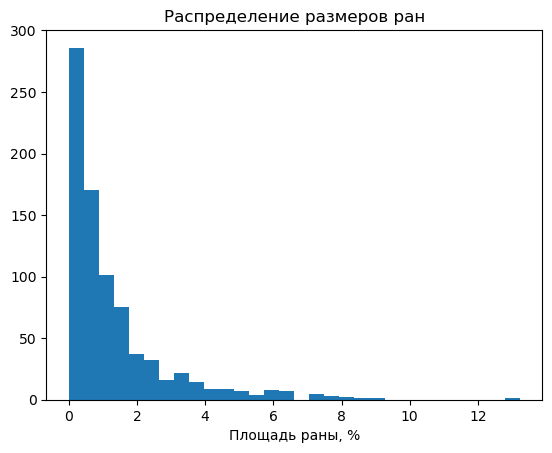

Медиана площади: 0.72%
Диапазон: 0.00% – 13.23%
Маленьких ран (<0.3 %): 214 из 810
Больших ран(>1.6 %): 197 из 810


In [4]:
# Гистограмма размера ран
plt.hist(stats_df["wound_ratio"] * 100, bins=30)
plt.xlabel("Площадь раны, %")
plt.title("Распределение размеров ран")
plt.show()

# Статистики
print(f"Медиана площади: {stats_df['wound_ratio'].median()*100:.2f}%")
print(f"Диапазон: {stats_df['wound_ratio'].min()*100:.2f}% – {stats_df['wound_ratio'].max()*100:.2f}%")

# Фильтрация: найти очень маленькие раны, очень большие раны
small_wounds = stats_df[stats_df["wound_ratio"] < 0.003]
print(f"Маленьких ран (<0.3 %): {len(small_wounds)} из {len(stats_df)}")
big_wounds = stats_df[stats_df["wound_ratio"] > 0.016]
print(f"Больших ран(>1.6 %): {len(big_wounds)} из {len(stats_df)}")

### Выводы после EDA

1. Сильный _class imbalance_ - необходимо использовать соответствующие функции потерь (Dice Loss, Tversky Loss).
2. Диапазон wound_ratio _0.00% – 13.23%_ - необходимо добавить RandomScale аугментации.
3. Средняя яркость _90 ± 14_ - добавить аугментации ColorJitter.
4. Много маленьких ран (25 %) - использовать Tversky Loss


### 3. Оценка качества разметки

Данные почерпнуты из статьи https://www.mdpi.com/2078-2489/15/3/140

Первичная разметка<br>
   • Неэкспертные аннотаторы в Photoshop (графические планшеты)<br>
   • Маски — отдельные слои поверх оригинальных изображений<br>

Экспертная валидация<br>
   • Проведена специалистами по раневому менеджменту (wound care specialists)<br>
   • Опыт экспертов: >20 лет работы с хроническими ранами<br>
   • Также участвовали медицинские ассистенты клиники, которые вели этих пациентов<br>

Разрешение спорных случаев:<br>
совместное обсуждение аннотационной команды и лаборатории, финальное решение принималось консенсусом


### 4. Описание алгоритма формирования выборки для решения задачи и стратегия валидации

Авторы датасета предоставили качественное разделение на train, validation и test.

Однако для исследовательского проекта также можно применить 5-fold cross-validation со стратификацией по размеру раны (больших и маленьких ран по 25 %, остальные средние), предварительно
объединив train и validation. В таком случае test можно использовать для финальной оценки качества модели.

In [5]:
# validation имеет схожие статистики, что и train, поэтому их можно объединить
stats_df_val = compute_dataset_stats(str(DATASET_PATH), split="validation")

100%|██████████| 200/200 [00:01<00:00, 170.45it/s]


In [6]:
stats_df_val.describe()

,wound_px,wound_ratio,brightness,contrast,wound_mean_R,wound_mean_G,wound_mean_B
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3204.400000,0.012224,90.137777,74.451186,156.954282,94.069798,82.268759
std,3947.329802,0.015058,14.011352,8.514881,56.363967,42.417096,35.229221
min,0.000000,0.000000,47.397808,44.195617,0.000000,0.000000,0.000000
25%,737.250000,0.002812,82.328123,69.524706,119.482987,69.132226,63.850186
50%,1887.000000,0.007198,90.501690,75.652477,172.975711,90.646936,83.687331
75%,3900.250000,0.014878,98.171598,80.365794,196.576523,118.813734,104.453376
max,20164.000000,0.076920,125.504684,92.379273,245.619444,212.883939,175.501758


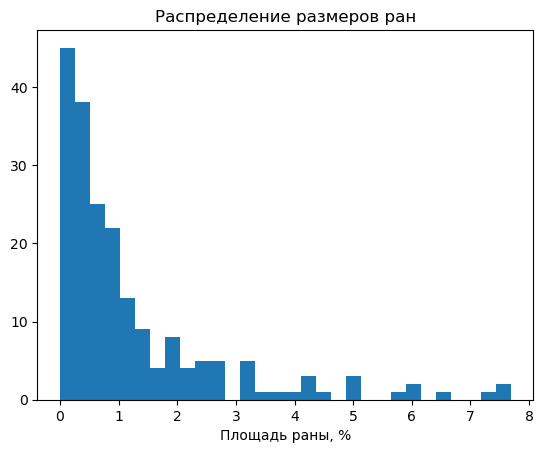

Медиана площади: 0.72%
Диапазон: 0.00% – 7.69%
Маленьких ран (<0.3 %): 53 из 200
Больших ран(>1.6 %): 47 из 200


In [7]:
# Гистограмма размера ран
plt.hist(stats_df_val["wound_ratio"] * 100, bins=30)
plt.xlabel("Площадь раны, %")
plt.title("Распределение размеров ран")
plt.show()

# Статистики
print(f"Медиана площади: {stats_df_val['wound_ratio'].median()*100:.2f}%")
print(f"Диапазон: {stats_df_val['wound_ratio'].min()*100:.2f}% – {stats_df_val['wound_ratio'].max()*100:.2f}%")

# Фильтрация: найти очень маленькие раны, очень большие раны
small_wounds = stats_df_val[stats_df_val["wound_ratio"] < 0.003]
print(f"Маленьких ран (<0.3 %): {len(small_wounds)} из {len(stats_df_val)}")
big_wounds = stats_df_val[stats_df_val["wound_ratio"] > 0.016]
print(f"Больших ран(>1.6 %): {len(big_wounds)} из {len(stats_df_val)}")